## This lecture is about TEXT PROCESSING FUNDAMENTALS

**Outline (from slides):** Regular Expressions → Tokenization → Normalization → Libraries & Toolkits

#### Healthcare text processing

1) PHI needs to be removed, names and dates/ DOB.
2) Not needed formatting things

**What the raw MIMIC clinical note looks like** (source: MIMIC, physionet.org) and what makes it messy:

- It is **plain text with no markup**, and lines are **artificially wrapped** with `\n` (every single `\n` is a wrap, `\n\n` is a real break).
- **Punctuation** everywhere: commas, apostrophes, quotes, question marks, and **acronyms** (CT, MD, Pt.).
- **Hyphenated** terms like `FOLLOW-UP`.
- **De-identified PHI** is replaced with placeholders like `[**First Name4 (NamePattern1) **]`, `[**Last Name (NamePattern1) 1407**]`, `[**Telephone/Fax (1) 1408**]`.
- **Dates** may need handling if they are not all in the same format (`[**2151-7-16**]`).
- **Formatting junk** such as `\n\n*******************\n\n`.

Goal of text processing: turn this into clean, consistent text before any model sees it.

In [3]:
import re

raw = ("\n\n*******************\n\nAdmission Date: [**2151-7-16**] Discharge Date: [**2151-8-4**]\n\n\nService:\nADDENDUM:\n\n"
       "HEAD CT: Head CT showed\nno intracranial hemorrhage or mass\neffect.\n\n"
       "FOLLOW-UP PLANS: The patient is recommended to followup with\nDr. [**First Name4 (NamePattern1) **] "
       "[**Last Name (NamePattern1) 1407**], [**Telephone/Fax (1) 1408**] within two\nweeks.")

clean = re.sub(r'\*{3,}', '', raw)                       # remove ***** formatting lines
clean = re.sub(r'\[\*\*(\d{4}-\d{1,2}-\d{1,2})\*\*\]', r'\1', clean)  # keep dates, drop [** **]
clean = re.sub(r'\[\*\*[^\]]*\*\*\]', '[PHI]', clean)      # replace other de-id placeholders
clean = re.sub(r'(?<!\n)\n(?!\n)', ' ', clean)            # single \n = artificial wrap -> space
clean = re.sub(r'\n{2,}', '\n', clean).strip()            # collapse real breaks
print(clean)

Admission Date: 2151-7-16 Discharge Date: 2151-8-4
Service: ADDENDUM:
HEAD CT: Head CT showed no intracranial hemorrhage or mass effect.
FOLLOW-UP PLANS: The patient is recommended to followup with Dr. [PHI] [PHI], [PHI] within two weeks.


#### Regular Expression

1) It is just a simple search, type of pattern matching,  it can account for typo,mis spelled, different spellings

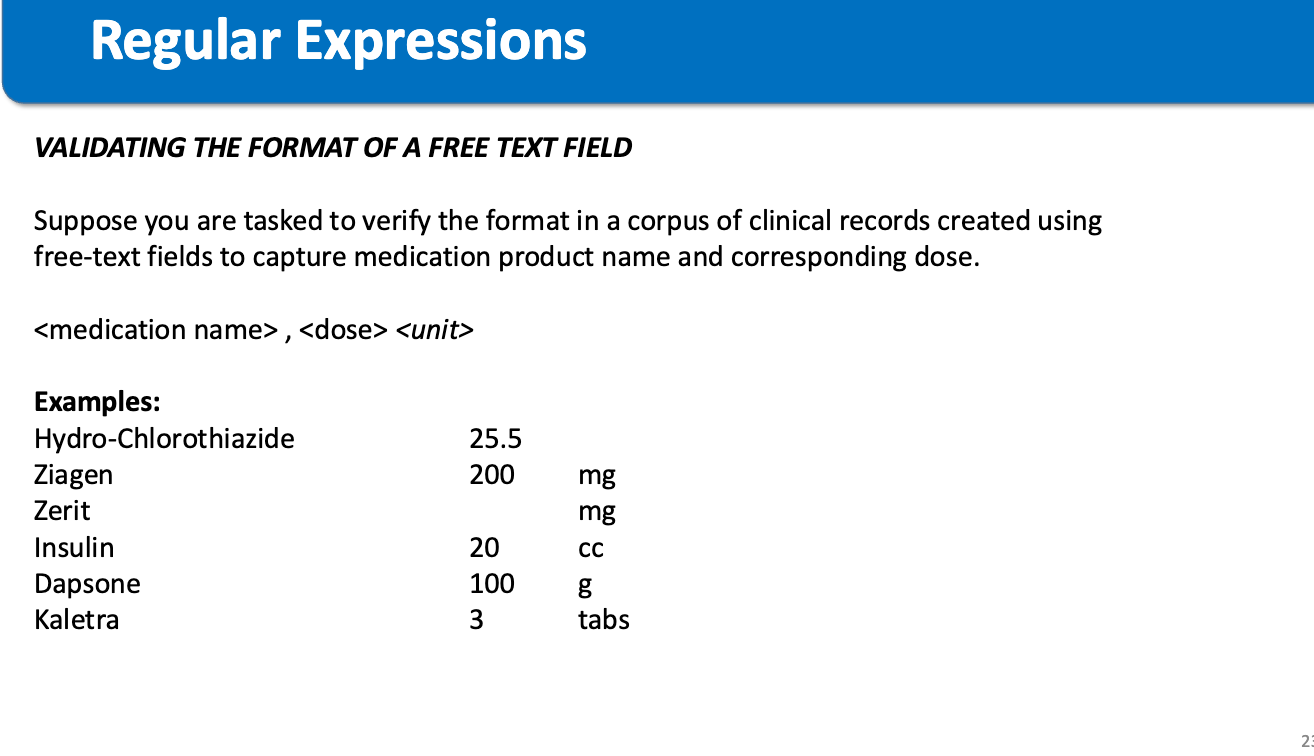

2) USES
 - COMPLEX SEARCH PATTERN
- Extracting text
- Text normalization

**Motivating examples from the slides (clinical data):**

| Task | Example |
|---|---|
| Simple search (misspellings) | Amoxicillin → "Amoxycillin", "Amoxycilin", "Amoxicilin", "Amoxcilin"; Metformin → "Metphormin", "Metformine", "Metforimn" |
| Validating format of a free-text field | `<medication name> , <dose> <unit>` e.g. Ziagen 200 mg, Insulin 100 g, Dapsone 3 tabs |
| Complex search pattern | find records mentioning two ADEs: "Headache and nausea", "Nausae and headache", "Pt. Rptd. Head ache and nausea", "Naus. And hdache reported" |
| Extracting text | extract ADEs reported **by patients**, not physicians: "Patient reported headache and nausea." vs "MD noticed rash." |
| Text normalization | standardize "multivitamin", "multi-vitamin", "multi-vita", "multivit", "multi-vit", "multi vitamin" |

**Definition:** a set of "instructions" given to a function on *what* and *how* to search, match, or replace a set of strings.

**History:**
- **1951** – mathematician **Stephen Cole Kleene** described the *regular language*: a language recognizable by a finite automaton and formally expressible using regular expressions.
- **Mid-1960s** – **Ken Thompson** (one of the original Unix designers) implemented pattern matching in the **QED** text editor using Kleene's notation.

In [2]:
# The misspelled-medication and multivitamin examples as regexes
meds = ["Amoxicillin", "Amoxycillin", "Amoxycilin", "Amoxicilin", "Amoxcilin", "Ampicillin"]
amox = re.compile(r'amox[iy]?cill?in', re.IGNORECASE)
print([m for m in meds if amox.fullmatch(m)])

vits = ["multivitamin", "multi-vitamin", "multi-vita", "multivit", "multi-vit", "multi vitamin"]
print([re.sub(r'multi[\s-]?vit\w*', 'multivitamin', v) for v in vits])

['Amoxicillin', 'Amoxycillin', 'Amoxycilin', 'Amoxicilin', 'Amoxcilin']
['multivitamin', 'multivitamin', 'multivitamin', 'multivitamin', 'multivitamin', 'multivitamin']


### Use Cases of Reg ex:
- Data pre-processing
- Rule-based information mining systems
- Pattern matching
- Text feature engineering
- Web scraping
- Data extraction

Python, Java, and Perl all support regex functionality, as do most Unix tools and many text editors.

## For python you can use the RE library to do that

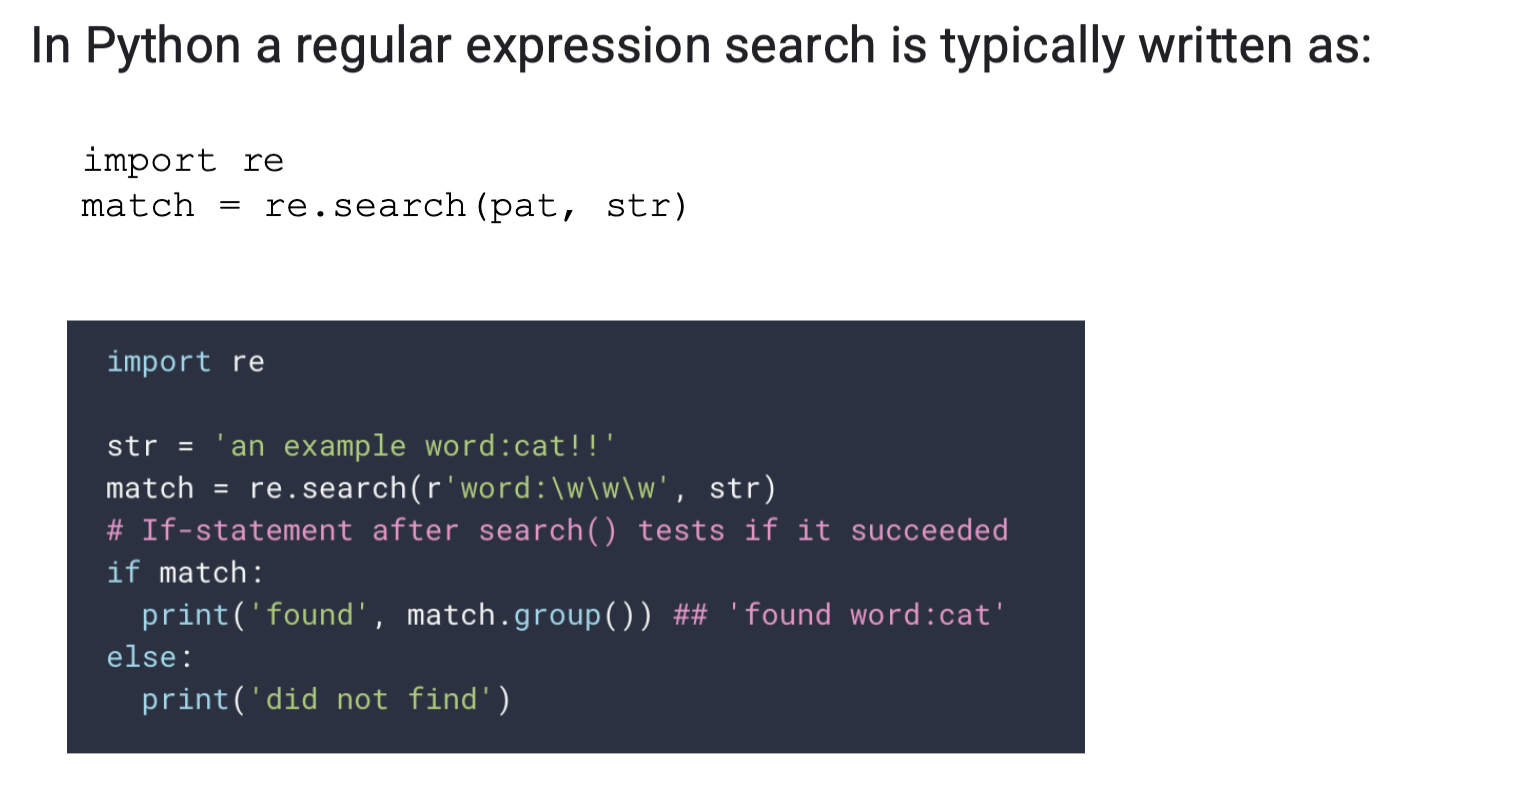

In Python a regex search is typically written as:
```python
import re
match = re.search(pat, str)   # returns a Match object, or None if not found
```
The slides use a small helper `test(match)` to print results, defined below.

In [3]:
import re

def test(match):
    if match:
        print('found:', match.group())
    else:
        print('did not find')

### Basics: ordinary characters
- `a, X, 9, <` : ordinary characters just match themselves exactly.
- **Meta-characters** do *not* match themselves because they have special meanings: `. ^ $ * + ? { [ ] \ | ( )`

In [4]:
## Search for pattern 'iii' in string 'piiig'.
## All of the pattern must match, but it may appear anywhere.
## On success, match.group() is matched text.
match = re.search(r'iii', 'piiig')
test(match)

found: iii


NOTE : r"path", here r means take it as is  

**Raw string:** the prefix `r` tells Python to treat backslashes as literal characters, not escape characters. This makes regex easier to read and write.
e.g. a word boundary is `r'\b'` as a raw string instead of `'\\b'` in a regular string.

- \d -> Digit
- \w -> word or char or digit or _
- r -> raw text
- \t -> tab
- \n -> new line
- \r -> return
- ^ -> start with that match, '^b', anything that start with b
- $ -> end with that match, 'b$', anything that ends with b

**More special characters (from the slides):**
- `.` (period) → any single character **except** newline `\n`
- `\W` → any **non**-word character. Note: `\w` matches a single word char `[a-zA-Z0-9_]`, not a whole word.
- `\b` → boundary between word and non-word
- `\s` → a single whitespace char (space, newline, return, tab, form feed `[ \n\r\t\f]`)
- `\S` → any non-whitespace character
- `\` → inhibits the "specialness" of a character: `\.` matches a period, `\\` matches a backslash

NOTE: if unsure whether a character is special (e.g. `@`), you can put a slash in front of it (`\@`). If it's not a valid escape sequence, like `\c`, Python will raise an error.

In [5]:
## . = any char but \n
test(re.search(r'..g', 'piiig'))

## \d = digit char
test(re.search(r'\d\d\d', 'p123g'))

## \w = word char
test(re.search(r'\w\w\w', '@@abcd!!'))

## \b = word boundary: 'cat' as a whole word only
test(re.search(r'\bcat\b', 'concatenate'))
test(re.search(r'\bcat\b', 'the cat sat'))

## ^ and $ anchors
test(re.search(r'^b\w+', 'foobar'))
test(re.search(r'^b\w+', 'bar foo'))

found: iig
found: 123
found: abc
did not find
found: cat
did not find
found: bar


### Important ones
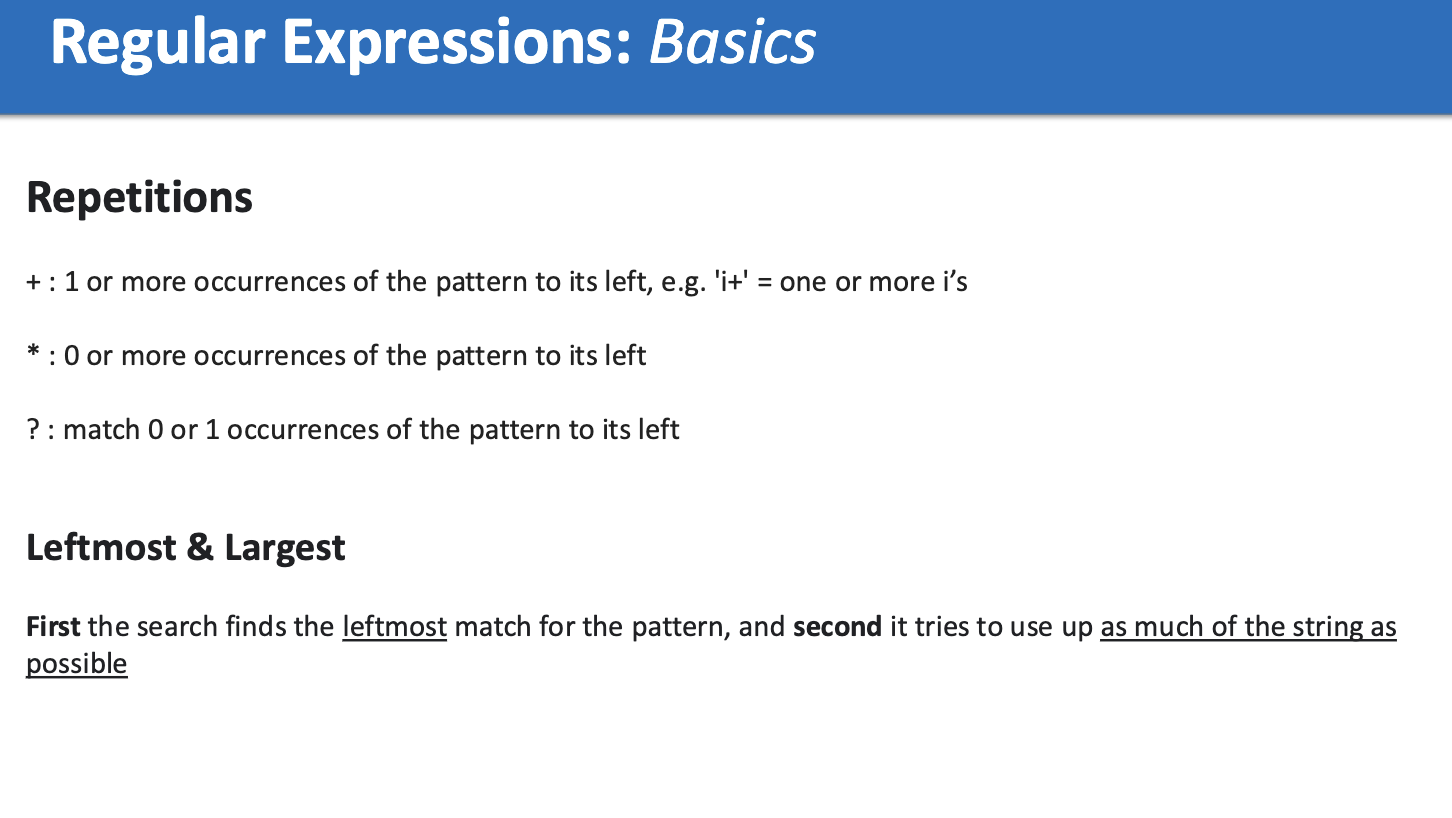



- pg, pig, piig, piiiig

- p+g : pig, piig, piiig
- p*g : pg, pig, piig, piiiig
- p?g : pg, pig


**Repetitions (from the slides):**
- `+` → 1 or more occurrences of the pattern to its left, e.g. `i+` = one or more i's
- `*` → 0 or more occurrences
- `?` → 0 or 1 occurrence
- `a{n}` → exactly n; `a{n,}` → n or more; `a{n,m}` → between n and m

**Leftmost & Largest:** the search first finds the *leftmost* match, and then tries to use up *as much of the string as possible*.

(Note: in the pig examples above the quantifier applies to the character to its left, so the patterns are really `pi+g`, `pi*g`, `pi?g`.)

In [6]:
## i+ = one or more i's, as many as possible.
test(re.search(r'pi+', 'piiig'))        # => "piii"

## Leftmost: it does not get to the second (longer) set of i's
test(re.search(r'i+', 'piigiiii'))      # => "ii"

## \s* = zero or more whitespace chars: 3 digits, possibly separated by whitespace
test(re.search(r'\d\s*\d\s*\d', 'xx1 2 3xx'))
test(re.search(r'\d\s*\d\s*\d', 'xx12 3xx'))
test(re.search(r'\d\s*\d\s*\d', 'xx123xx'))

## pig family
words = ['pg', 'pig', 'piig', 'piiig']
for p in [r'pi+g', r'pi*g', r'pi?g', r'pi{2}g', r'pi{2,}g', r'pi{1,2}g']:
    print(f'{p:10}', [w for w in words if re.fullmatch(p, w)])

found: piii
found: ii
found: 1 2 3
found: 12 3
found: 123
pi+g       ['pig', 'piig', 'piiig']
pi*g       ['pg', 'pig', 'piig', 'piiig']
pi?g       ['pg', 'pig']
pi{2}g     ['piig']
pi{2,}g    ['piig', 'piiig']
pi{1,2}g   ['pig', 'piig']


### Square brackets and negation
- `[abc]` matches `'a'` or `'b'` or `'c'`. Ranges work too: `[a-z]`, `[0-9]`.
- `\w`, `\s`, etc. work inside brackets too, except that `.` inside brackets means a **literal dot**.
- `^` **immediately after** `[` means negation:
  - `[^0-9]` → any character that is not a digit
  - `[^A-Za-z]` → any character that is not a letter
  - `[^aeiou]` → any character that is not a vowel

In [7]:
print(re.findall(r'[aeiou]', 'regular expression'))
print(re.findall(r'[^0-9]+', 'Dose: 200mg x3'))

['e', 'u', 'a', 'e', 'e', 'i', 'o']
['Dose: ', 'mg x']


### Worked example: email matcher
```
[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}
```
| Part | Meaning |
|---|---|
| `[a-zA-Z0-9._%+-]` | character class: lowercase, uppercase, digits, `.` `_` `%` `+` `-` |
| `+` | one or more of the preceding element (local part) |
| `@` | literal `@`, separates local part from domain |
| `[a-zA-Z0-9.-]+` | domain: letters, digits, dots, hyphens, one or more |
| `\.` | literal dot (a bare `.` would match any character, so it's escaped) |
| `[a-zA-Z]{2,}` | top-level domain (.com, .org, …), at least 2 characters |

In [8]:
email_re = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
print(re.findall(email_re, 'contact: john.doe@northeastern.edu, bad@x, jane_d+nlp@mail.co.uk'))

['john.doe@northeastern.edu', 'jane_d+nlp@mail.co.uk']


### Group extraction
Parentheses `( )` create logical **groups** inside the match.
- `match.group()` → the whole match
- `match.group(1)` → text of the 1st left parenthesis, `match.group(2)` → 2nd, …

In [9]:
s = 'purple alice-b@google.com monkey dishwasher'
match = re.search(r'([\w.-]+)@([\w.-]+)', s)
if match:
    print(match.group())    ## 'alice-b@google.com' (the whole match)
    print(match.group(1))   ## 'alice-b' (the username, group 1)
    print(match.group(2))   ## 'google.com' (the host, group 2)

alice-b@google.com
alice-b
google.com


### `findall`
Finds **all** matches and returns them as a list of strings. With groups, it returns a list of tuples.

In [7]:
s = 'purple alice@google.com, blah monkey bob@abc.com blah dishwasher'
emails = re.findall(r'[\w\.-]+@[\w\.-]+', s)
for email in emails:
    print(email)

## with groups -> list of tuples
print(re.findall(r'([\w\.-]+)@([\w\.-]+)', s))

alice@google.com
bob@abc.com
[('alice', 'google.com'), ('bob', 'abc.com')]


### Greedy vs non-greedy
Text with tags: `<b>foo</b> and <i>so on</i>`. Goal: match **each tag** with `(<.*>)`.
- **Greedy** `(<.*>)` → `.*` grabs as much as possible, so it matches from the first `<` to the *last* `>`.
- **Non-greedy** `(<.*?>)` → adding `?` makes it stop at the first `>`.

In [8]:
import re
text = '<b>foo</b>'
pattern = '<.*>'
match = re.search(pattern, text)
print(match.group())

<b>foo</b>


In [9]:
text = '<b>foo</b> and <i>so on</i>'
print('greedy    :', re.findall(r'(<.*>)', text))
print('non-greedy:', re.findall(r'(<.*?>)', text))

greedy    : ['<b>foo</b> and <i>so on</i>']
non-greedy: ['<b>', '</b>', '<i>', '</i>']


### Substitute: `re.sub(pat, replacement, str)`
Replaces all instances of the pattern. The replacement can use `\1`, `\2`, … to refer to `group(1)`, `group(2)`, … of the match.

In [10]:
s = 'purple alice@google.com, blah monkey bob@abc.com blah dishwasher'
print(re.sub(r'([\w\.-]+)@([\w\.-]+)', r'\1@yo-yo-dyne.com', s))

purple alice@yo-yo-dyne.com, blah monkey bob@yo-yo-dyne.com blah dishwasher


### Compile: `re.compile(pat)`
Compiles a pattern into a regex object that can be reused for matching, searching, finding all, and replacing (useful when the same pattern is applied many times).

In [11]:
pattern = re.compile(r'\d+')          # one or more digits
result = pattern.search("The answer is 42")
if result:
    print("Found number:", result.group())
print(pattern.findall("BP 120/80, HR 72"))

Found number: 42
['120', '80', '72']


### Regex cheat sheet
| Symbol | Meaning | Symbol | Meaning |
|---|---|---|---|
| `.` | any char except `\n` | `[abc]` | a, b, or c |
| `\d` / `\D` | digit / non-digit | `[^abc]` | not a, b, c |
| `\w` / `\W` | word char / non-word | `a*` | 0 or more |
| `\s` / `\S` | whitespace / non-whitespace | `a+` | 1 or more |
| `\b` | word boundary | `a?` | 0 or 1 |
| `^` / `$` | start / end of string | `a{n,m}` | n to m times |
| `\` | escape special char | `*?`, `+?` | non-greedy |
| `( )` | group | `a\|b` | a or b |

## Tokenization

- Definition - Tokenization is the process of splitting a piece of text into smaller units, called tokens

- Tokens can be words, numbers, or punctuation marks

- Types of tokenization
    - word
    - character
    - subword


**Tokenization techniques (overview):** White-space, Dictionary-based, Rule-based, Penn Tree, spaCy tokenizer, Moses tokenizer, and **Subword** tokenization (Byte-Pair Encoding, WordPiece, SentencePiece, Unigram language model).

### Why Tokenization

- Building blocks of text in natural language

- Most of the preprocessing and modeling happens at the **token level**.
- Neural network architectures process individual tokens to make sense of the document.

### Word-level tokenization
- Simplest method: break text into words using a **delimiter** (white-space, punctuation, etc.).

`"This is a lame example, isn't it?"`

| Delimiter | Tokens |
|---|---|
| white-space | `["This", "is", "a", "lame", "example,", "isn't", "it?"]` |
| white-space + punctuation | `["This", "is", "a", "lame", "example", ",", "isn", "'", "t", "it", "?"]` |
| smarter rules (e.g. NLTK) | `["This", "is", "a", "lame", "example", ",", "is", "n't", "it", "?"]` |

**Problems:** plural forms (`examples`) and misspellings (`exmples`) become **OOV** (Out Of Vocabulary) tokens.

**Limitations:**
- very large vocabulary size
- large number of OOV tokens
- different meaning of very similar words

NOTE: Transformer XL uses space + punctuation tokenization and has a vocabulary size of **267,735**.

### Character-level tokenization
- Split raw text into individual characters: `["T", "h", "i", "s", " ", "i", "s", ...]`
- Simple and can greatly reduce memory and time complexity (tiny vocabulary).

**Limitations:** very long sequences, and individual tokens are less meaningful.

### Subword-level tokenization
- A solution **between** word- and character-level.
- Addresses vocabulary explosion and OOV problems; better handling of rare and morphologically rich words.

**Principles:**
- Do **not** split frequently used words into smaller subwords.
- **Split rare words** into smaller meaningful subwords.

**Benefits:**
- The model learns that words with the same root are similar in meaning.
- It learns that "tokenization" and "modernization" have different roots but the same suffix "ization", used in the same syntactic situations.

A special symbol marks word-internal pieces, e.g. `"tokenization"` → `"token"`, `"##ization"`.

In [15]:
text = "This is a lame example, isn't it?"
print('white-space        :', text.split())
print('white-space + punct:', re.findall(r"\w+|[^\w\s]", text))
print('character          :', list(text)[:12], '...')

white-space        : ['This', 'is', 'a', 'lame', 'example,', "isn't", 'it?']
white-space + punct: ['This', 'is', 'a', 'lame', 'example', ',', 'isn', "'", 't', 'it', '?']
character          : ['T', 'h', 'i', 's', ' ', 'i', 's', ' ', 'a', ' ', 'l', 'a'] ...


### Common algorithms:
- Byte-Pair Encoding (BPE) (Sennrich et al., 2016)
- Unigram language modeling tokenization (Kudo, 2018)
- WordPiece (Schuster and Nakajima, 2012)
- SentencePiece (Kudo and Richardson, 2018)

**Methodology** (all subword algorithms have two parts):
- **Token learner**: takes a raw training corpus and induces a vocabulary (a set of tokens).
- **Token segmenter**: takes a raw test sentence and tokenizes it according to that vocabulary.

## 1 Byte- Pair Encoding

- Simple form of data compression algorithm in which the most common pair of consecutive bytes of data is replaced with a byte that does not occur in that data

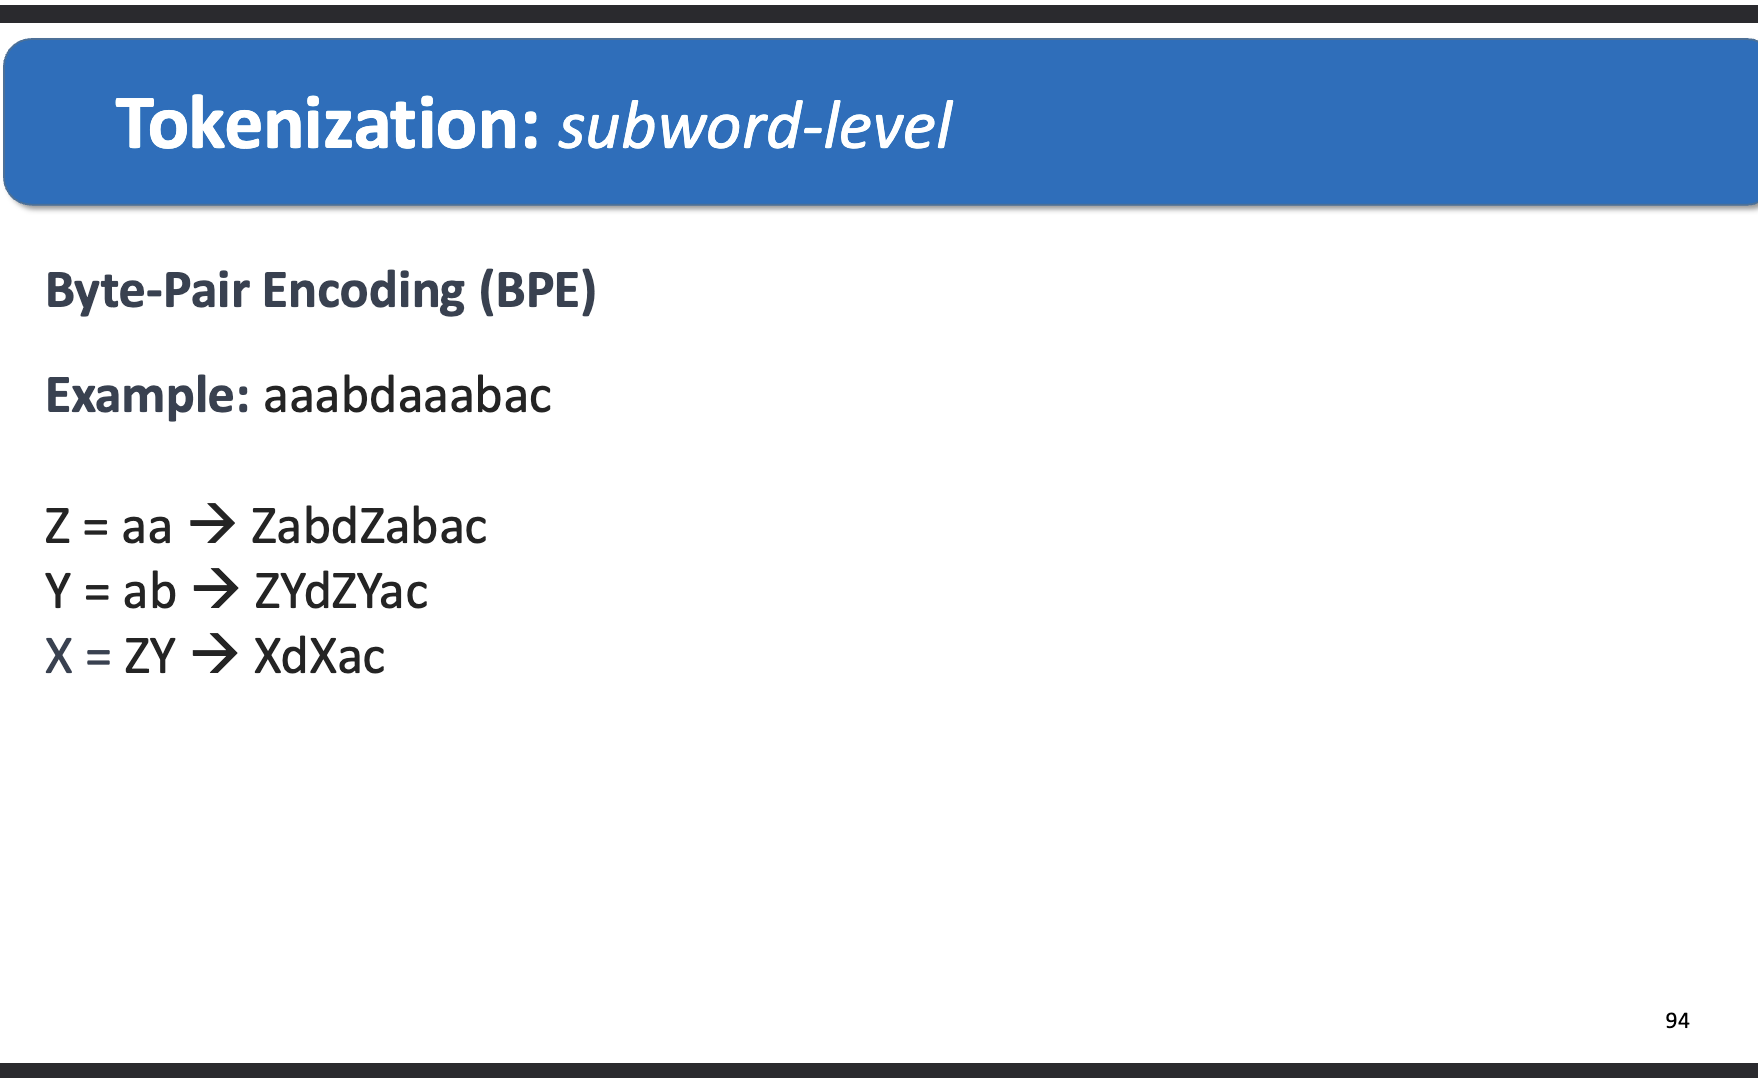
- 



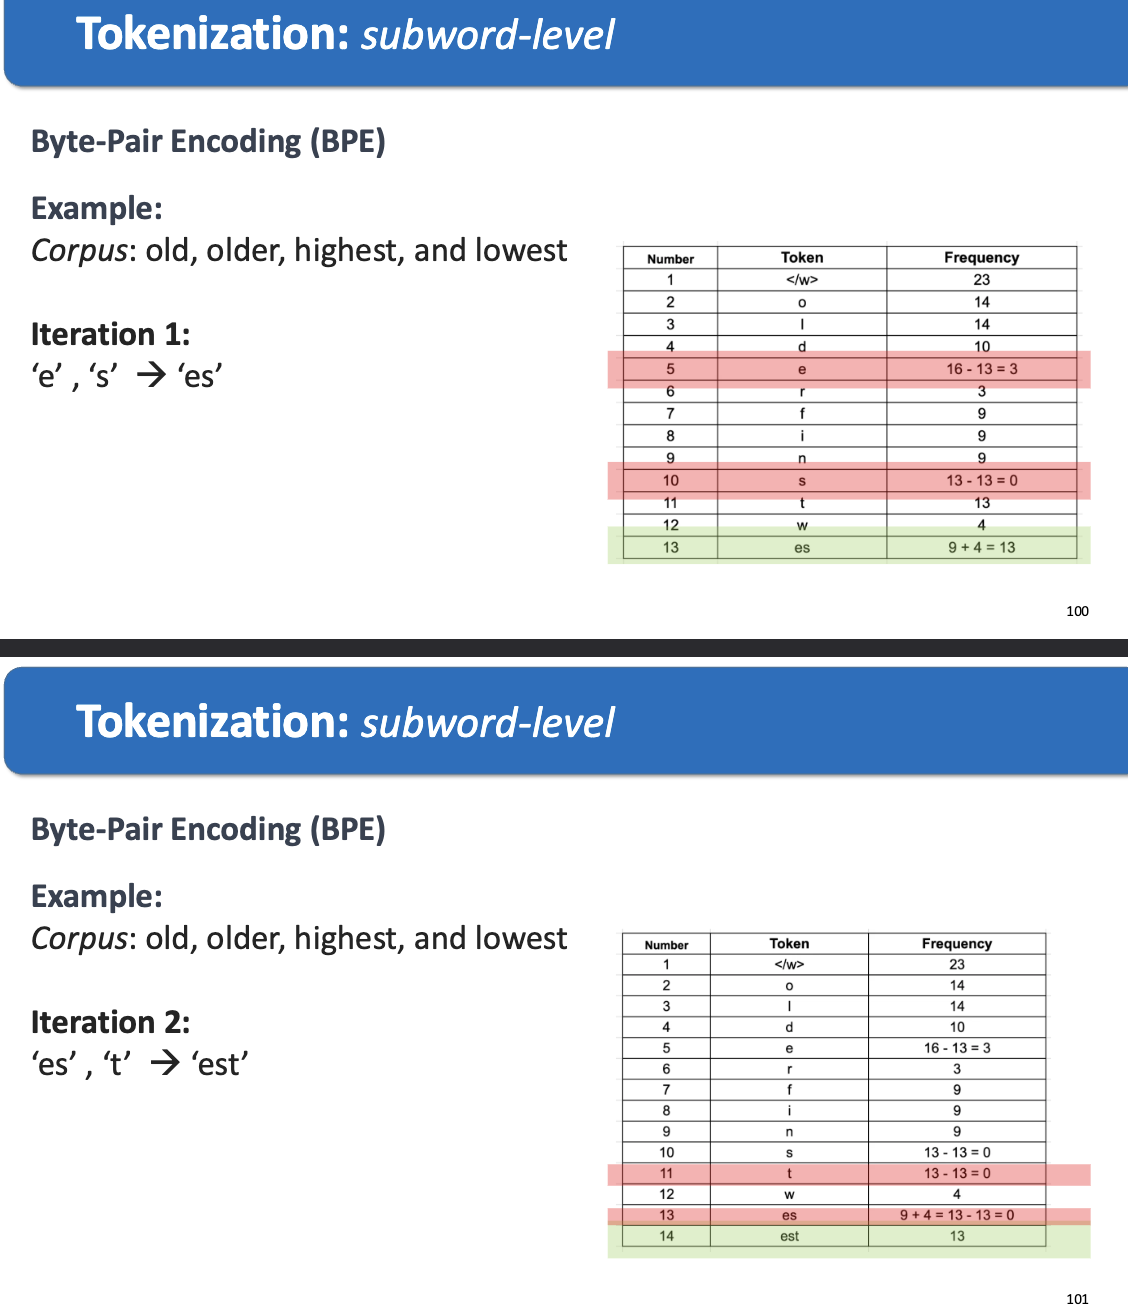


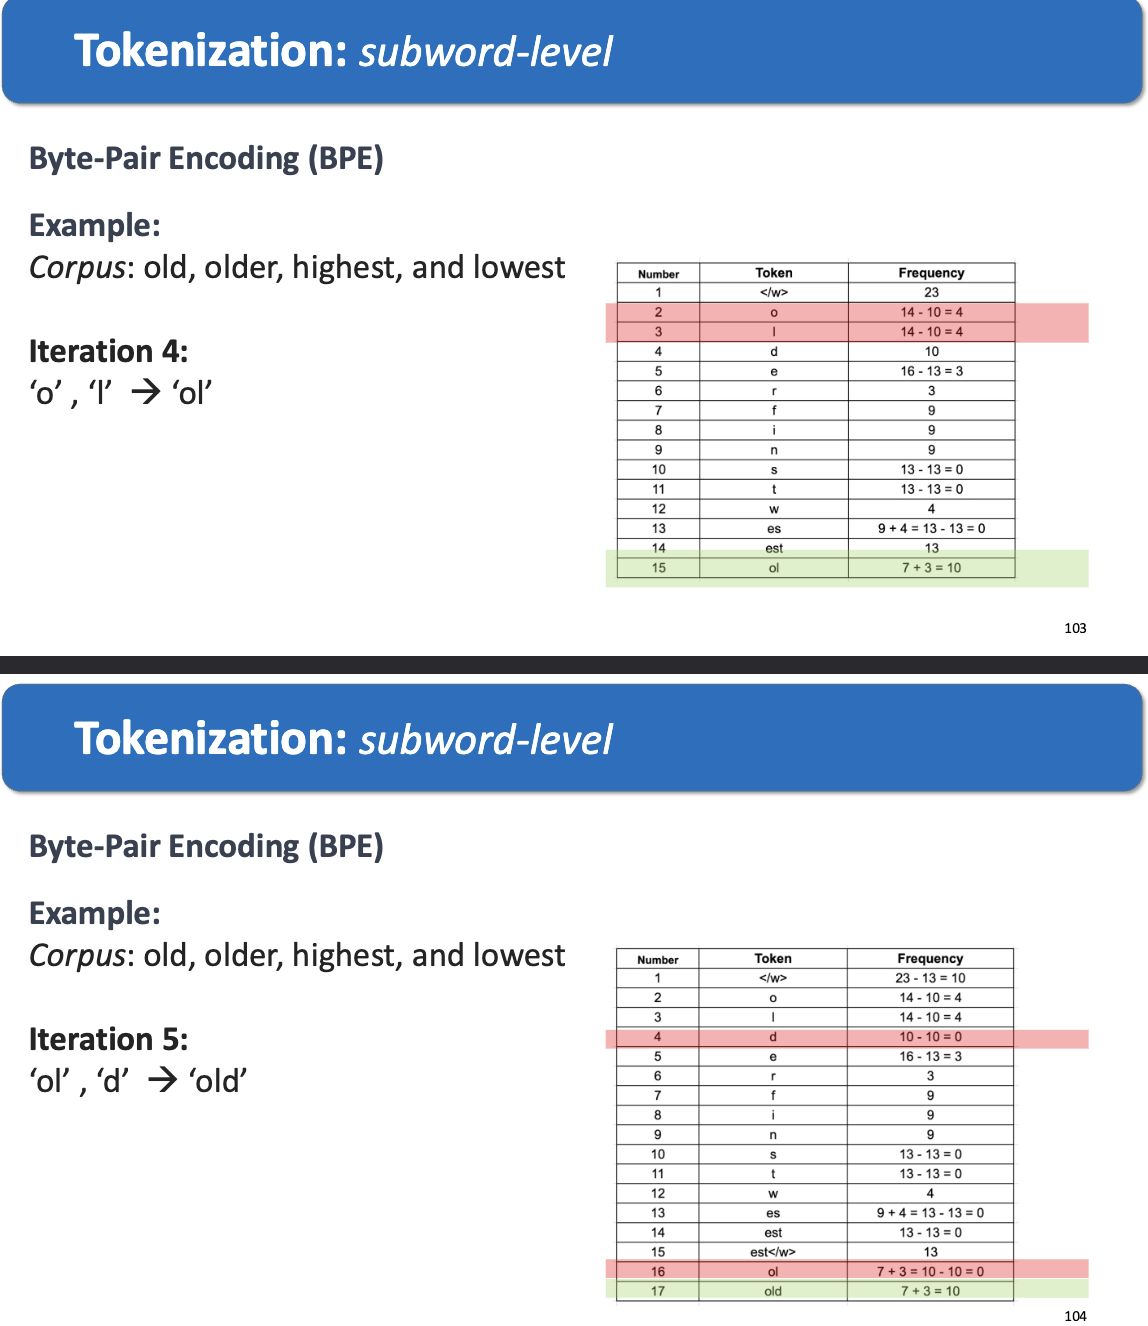


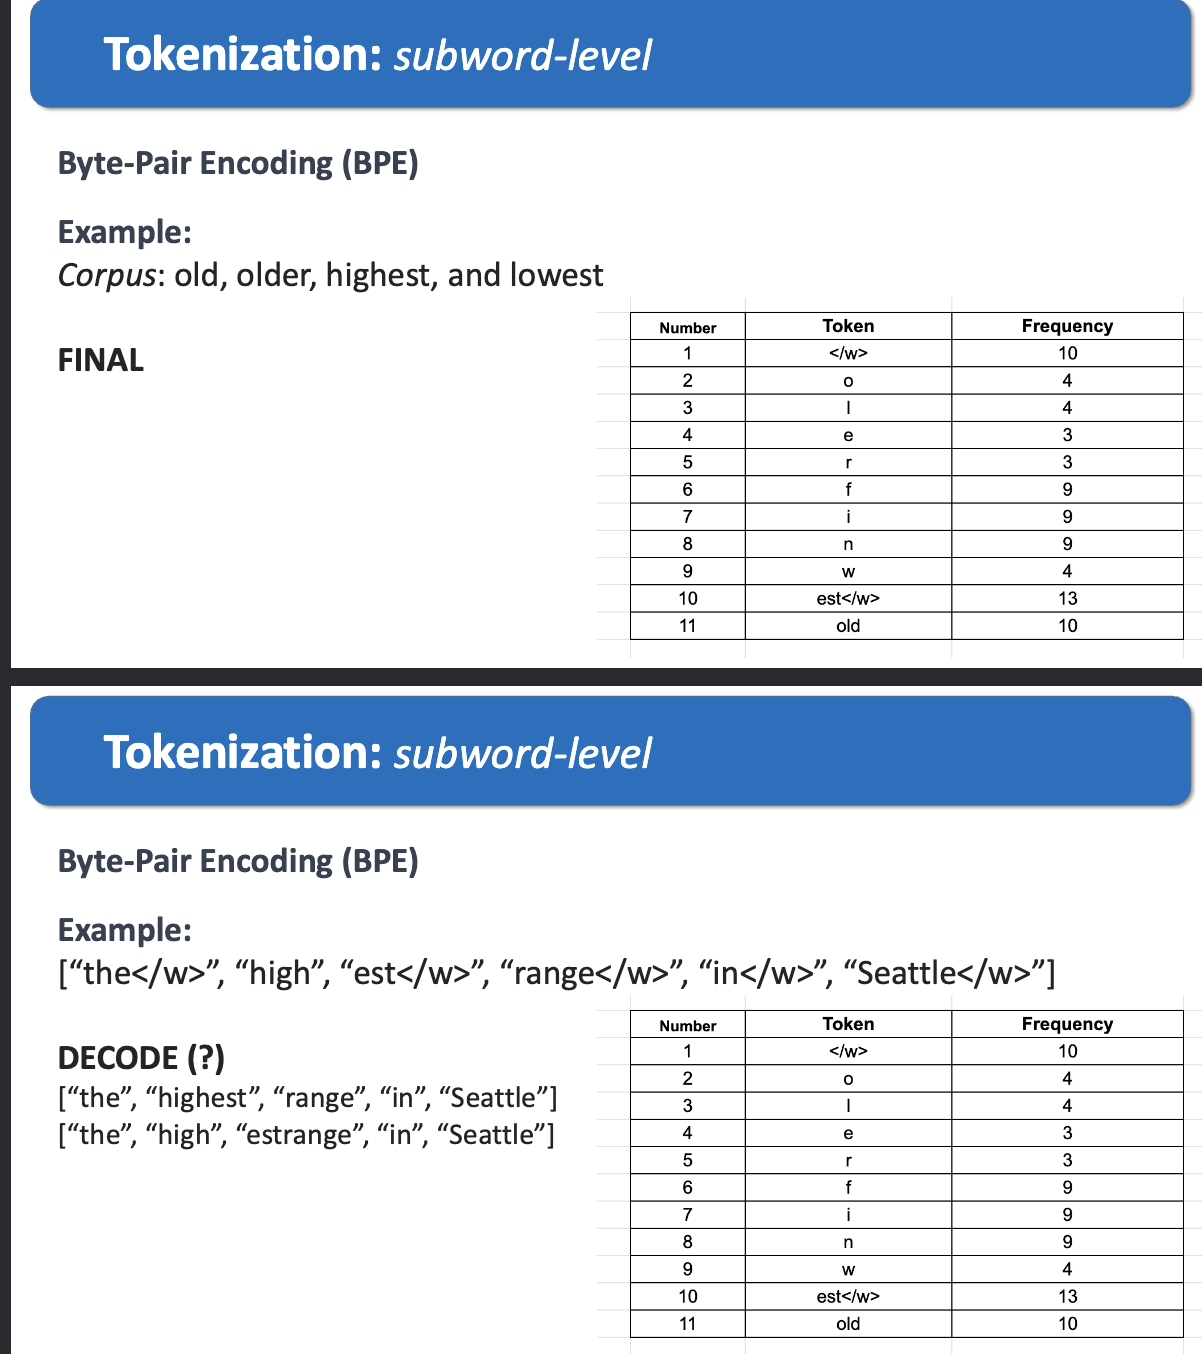


- First described in *"A New Algorithm for Data Compression"* (**1994**); adapted to NLP by Sennrich et al., 2016.
- Used in **GPT-2, RoBERTa, XLM, FlauBERT**, etc.

**Algorithm:**
```
function BYTE-PAIR ENCODING(strings C, number of merges k) returns vocab V
    V <- all unique characters in C              # initial set of tokens is characters
    for i = 1 to k do                            # merge tokens k times
        tL, tR <- most frequent pair of adjacent tokens in C
        tNEW <- tL + tR                          # make new token by concatenating
        V <- V + tNEW                            # update the vocabulary
        replace each occurrence of tL, tR in C with tNEW   # and update the corpus
    return V
```

**Compression example:** `aaabdaaabac`
1. `Z = aa` → `ZabdZabac`
2. `Y = ab` → `ZYdZYac`
3. `X = ZY` → `XdXac`

(If instead we picked `Y = Za`: `ZabdZabac` → `YbdYbac`, then `Yb → X` also gives `XdXac`.)

**NLP example:** corpus `{"old": 7, "older": 3, "highest": 9, "lowest": 4}`
1. Add an end-of-word token `</w>` to each word: `{"old</w>": 7, "older</w>": 3, "highest</w>": 9, "lowest</w>": 4}`
2. Split into characters, count, then merge the most frequent pair each iteration:
   - Iter 1: `e` + `s` → `es` (9 + 4 = 13)
   - Iter 2: `es` + `t` → `est` (13)
   - Iter 3: `est` + `</w>` → `est</w>` (13)
   - Iter 4: `o` + `l` → `ol` (7 + 3 = 10)
   - Iter 5: `ol` + `d` → `old` (10)

**Why `</w>` matters (decoding):** `["the</w>", "high", "est</w>", "range</w>", "in</w>", "Seattle</w>"]` decodes unambiguously to `the highest range in Seattle`. Without it, it could also be `the high estrange in Seattle`.

**Note:** whitespace-delimited languages must be **pre-tokenized** before BPE, so BPE does **not cross word boundaries** (e.g. a subword `"e_n"` won't be generated from "The nodule").

In [16]:
from collections import Counter

def get_pair_counts(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for a, b in zip(symbols, symbols[1:]):
            pairs[(a, b)] += freq
    return pairs

def merge_pair(pair, vocab):
    pattern = re.compile(r'(?<!\S)' + re.escape(' '.join(pair)) + r'(?!\S)')
    return {pattern.sub(''.join(pair), w): f for w, f in vocab.items()}

corpus = {"old": 7, "older": 3, "highest": 9, "lowest": 4}
vocab = {' '.join(w) + ' </w>': f for w, f in corpus.items()}   # char split + end token

merges = []
for i in range(5):
    pairs = get_pair_counts(vocab)
    best = max(pairs, key=pairs.get)
    vocab = merge_pair(best, vocab)
    merges.append(best)
    print(f'Iteration {i+1}: {best} -> {"".join(best)!r}  (count {pairs[best]})')

print('\nFinal segmentation:', vocab)

Iteration 1: ('e', 's') -> 'es'  (count 13)
Iteration 2: ('es', 't') -> 'est'  (count 13)
Iteration 3: ('est', '</w>') -> 'est</w>'  (count 13)
Iteration 4: ('o', 'l') -> 'ol'  (count 10)
Iteration 5: ('ol', 'd') -> 'old'  (count 10)

Final segmentation: {'old </w>': 7, 'old e r </w>': 3, 'h i g h est</w>': 9, 'l o w est</w>': 4}


In [17]:
def bpe_segment(word, merges):
    """Token segmenter: apply learned merges, in order, to a new word."""
    symbols = list(word) + ['</w>']
    for a, b in merges:
        i = 0
        while i < len(symbols) - 1:
            if symbols[i] == a and symbols[i+1] == b:
                symbols[i:i+2] = [a + b]
            else:
                i += 1
    return symbols

for w in ['oldest', 'lowest', 'bold', 'newest']:
    print(w, '->', bpe_segment(w, merges))

oldest -> ['old', 'est</w>']
lowest -> ['l', 'o', 'w', 'est</w>']
bold -> ['b', 'old', '</w>']
newest -> ['n', 'e', 'w', 'est</w>']


## 2 Unigram language modeling tokenization

- 

- **Opposite of BPE:** starts with a **large** base vocabulary and progressively **trims** it down to the desired size.
- Treats tokenization as a **probabilistic** process: learns which tokens best explain the training corpus.
- Not used directly by models in 🤗 Transformers, but used **together with SentencePiece** (e.g. T5, XLNet, ALBERT).

**Background:**
- *Language model:* given a sequence of words, predict what comes next.
- *Unigram LM:* assumes independence between tokens, so
  $P(x_1, \dots, x_N) = p(x_1) \times p(x_2) \times \dots \times p(x_N) = \prod_i p(x_i)$

**Method:**
1. Define a loss (negative log-likelihood) over the training data given the current vocabulary:
   $\mathcal{L} = \sum_{words} freq \times (-\log P(word))$, where $P(word)$ is the probability of its **best** segmentation.
2. For each symbol, compute how much the loss would **increase** if it were removed.
3. Remove **p%** (usually 10–20%) of symbols with the lowest loss increase (base characters are always kept so every word can be tokenized).
4. Repeat until the vocabulary reaches the desired size.

**Example from slides:** corpus `hug:10, pug:12, lug:5, bug:4, dug:5`
- Initial vocab: `h u g l b d p hu ug pu lu du bu` (total substring freq = 180)
- e.g. `p(h)=10/180, p(u)=36/180, p(g)=36/180, p(hu)=10/180, p(ug)=36/180`
- For "hug": `h+u+g = 2.22e-03`, `hu+g = 1.11e-02`, `h+ug = 1.11e-02` → best segmentation has p = 1.11e-02
- Iteration 1 loss: **ℒ = 170.40**. Removing `ug` does not change the loss → it is dropped.
- Iteration 2 (total 144): slides give **ℒ = 168.20** (scoring hug as h+u+g); using the best split hu+g gives 154.34 (see code). Pruning then continues (next candidates to drop: du, bu, …).

In [18]:
import math
from itertools import combinations

corpus = {"hug": 10, "pug": 12, "lug": 5, "bug": 4, "dug": 5}
vocab0 = ['h','u','g','l','b','d','p','hu','ug','pu','lu','du','bu']

def token_probs(vocab):
    freq = {t: sum(f * sum(1 for i in range(len(w)) if w.startswith(t, i)) for w, f in corpus.items()) for t in vocab}
    total = sum(freq.values())
    return {t: c / total for t, c in freq.items()}, total

def best_seg(word, probs):
    """Viterbi: best segmentation of word under unigram probs."""
    best = [(1.0, [])] + [(0.0, None)] * len(word)
    for end in range(1, len(word) + 1):
        for start in range(end):
            piece = word[start:end]
            if piece in probs and best[start][1] is not None:
                p = best[start][0] * probs[piece]
                if p > best[end][0]:
                    best[end] = (p, best[start][1] + [piece])
    return best[-1]

def loss(vocab, probs=None):
    probs = probs or token_probs(vocab)[0]
    return sum(f * -math.log(best_seg(w, probs)[0]) for w, f in corpus.items())

probs, total = token_probs(vocab0)
print('Iteration 1, Step 1: total =', total)
for w in corpus:
    p, seg = best_seg(w, probs)
    print(f'  {w}: {"+".join(seg)} = {p:.2e}')
print(f'  loss = {loss(vocab0):.2f}')

# Step 2: loss if each non-base symbol is removed (probabilities of the others kept fixed)
print('Iteration 1, Step 2:')
for t in ['hu','ug','pu','lu','du','bu']:
    p_wo = {k: v for k, v in probs.items() if k != t}
    print(f'  remove {t!r:5} -> loss {loss(vocab0, p_wo):.2f}')
# every removal gives 170.40 (tie) -> the slides drop 'ug'

vocab1 = [v for v in vocab0 if v != 'ug']
probs1, total1 = token_probs(vocab1)
print(f'Iteration 2: total = {total1}')
for w in corpus:
    p, seg = best_seg(w, probs1)
    print(f'  {w}: {"+".join(seg)} = {p:.2e}')
print(f'  loss = {loss(vocab1):.2f}')
# Note: the slides score "hug" as h+u+g (4.34e-03) in iteration 2, giving 168.20;
# the best segmentation hu+g (1.74e-02) gives the lower loss shown here.

Iteration 1, Step 1: total = 180
  hug: h+ug = 1.11e-02
  pug: p+ug = 1.33e-02
  lug: l+ug = 5.56e-03
  bug: b+ug = 4.44e-03
  dug: d+ug = 5.56e-03
  loss = 170.40
Iteration 1, Step 2:
  remove 'hu'  -> loss 170.40
  remove 'ug'  -> loss 170.40
  remove 'pu'  -> loss 170.40
  remove 'lu'  -> loss 170.40
  remove 'du'  -> loss 170.40
  remove 'bu'  -> loss 170.40
Iteration 2: total = 144
  hug: hu+g = 1.74e-02
  pug: pu+g = 2.08e-02
  lug: lu+g = 8.68e-03
  bug: bu+g = 6.94e-03
  dug: du+g = 8.68e-03
  loss = 154.34


**BPE vs Unigram LM** (from ndingwall.github.io/blog/tokenization):
- Unigram LM recovers common suffixes like `ly`, `s`, `ing` much more often than BPE → produces more **morphologically interpretable** tokens (e.g. "stabilizing" / "destabilizing").
- **Speed:** Unigram LM gets *faster* to learn as vocab size increases.
- **Inference:** the difference is insignificant.

## 3 WordPiece




- Developed by **Google** to pretrain **BERT**; reused in DistilBERT, MobileBERT, Funnel Transformers, MPNET.
- Training is **very similar to BPE**, but the pair to merge is chosen differently, and the actual tokenization is done differently.

**Method:**
1. Split each word into characters, adding the prefix `##` to all characters inside the word: `word` → `w ##o ##r ##d`
2. Like BPE, learn merge rules, but instead of the most **frequent** pair, pick the pair with the highest **score**:

$$score = \frac{freq\_of\_pair}{freq\_of\_first\_element \times freq\_of\_second\_element}$$

3. Highest score → **merge**. Repeat until the desired vocabulary size is reached.

**Intuition:** if two pairs occur equally often, the one whose individual parts are **less frequent** gets a higher score. WordPiece prioritizes merging pairs whose parts rarely appear on their own.

**At tokenization time** (e.g. `huggingface`), WordPiece does **not** replay merges. It uses **greedy longest-match-first**: find the longest subword in the vocab that the word starts with, split it off, repeat on the rest (`##`-prefixed).
`huggingface` → `huggi` + `##n` + `##gface`… (depends on vocabulary; if no piece matches, the whole word becomes `[UNK]`).

In [19]:
def wordpiece_scores(word_freqs):
    splits = {w: [w[0]] + ['##' + c for c in w[1:]] for w in word_freqs}
    letter, pair = Counter(), Counter()
    for w, f in word_freqs.items():
        s = splits[w]
        for t in s: letter[t] += f
        for a, b in zip(s, s[1:]): pair[(a, b)] += f
    return {p: c / (letter[p[0]] * letter[p[1]]) for p, c in pair.items()}, pair

scores, pair_freq = wordpiece_scores({"hug": 10, "pug": 5, "pun": 12, "bun": 4, "hugs": 5})
for p, s in sorted(scores.items(), key=lambda x: -x[1])[:5]:
    print(f'{p}: freq={pair_freq[p]:2d}  score={s:.4f}')
print('\nBPE would merge the most frequent pair:', max(pair_freq, key=pair_freq.get))
print('WordPiece merges the highest score  :', max(scores, key=scores.get))

('##g', '##s'): freq= 5  score=0.0500
('h', '##u'): freq=15  score=0.0278
('##u', '##g'): freq=20  score=0.0278
('p', '##u'): freq=17  score=0.0278
('##u', '##n'): freq=16  score=0.0278

BPE would merge the most frequent pair: ('##u', '##g')
WordPiece merges the highest score  : ('##g', '##s')


In [20]:
def wordpiece_tokenize(word, vocab):
    """Greedy longest-match-first, as used by BERT at inference."""
    tokens, start = [], 0
    while start < len(word):
        end = len(word)
        while end > start:
            piece = word[start:end] if start == 0 else '##' + word[start:end]
            if piece in vocab:
                tokens.append(piece); break
            end -= 1
        else:
            return ['[UNK]']
        start = end
    return tokens

toy_vocab = {'hug', 'huggi', '##n', '##g', '##face', '##gface', '##s', 'b', '##u'}
for w in ['huggingface', 'hugs', 'bug', 'xyz']:
    print(w, '->', wordpiece_tokenize(w, toy_vocab))

huggingface -> ['huggi', '##n', '##gface']
hugs -> ['hug', '##s']
bug -> ['b', '##u', '##g']
xyz -> ['[UNK]']


## 4 SentencePiece


- Proposed as a **language-independent**, **pre-tokenization-free** tokenizer that models raw text directly.
- Enables uniform preprocessing and integrates seamlessly into neural pipelines.
- Used for **XLNet** (Yang et al. 2019) and **mBART** (Liu et al. 2020); also T5, ALBERT.

**How it works:**
1. Treat input as a sequence of **Unicode characters**: works on raw text (not whitespace-split words) and encodes the space itself as a special symbol `▁`.
   `"Hello world"` → `["▁Hello", "▁world"]`
2. Unsupervised subword training using either **BPE** or the **Unigram LM**.

Because spaces are kept as `▁`, decoding is lossless: just concatenate and replace `▁` with a space. This works for languages without spaces (Chinese, Japanese).

### Summary: subword algorithms

| Tokenizer | Core idea | Basis for merging | Computation | Commonly used in |
|---|---|---|---|---|
| **BPE** | start from characters, iteratively merge the most frequent pair | Frequency-based | Efficient, greedy | GPT models, OpenAI models, RoBERTa |
| **Unigram** | start from a large vocab, prune tokens to maximize data likelihood | Probabilistic | More expensive | T5, Japanese tokenization |
| **WordPiece** | like BPE, but merges pairs that increase likelihood (score formula) | Likelihood-based | Moderately efficient | BERT, DistilBERT |
| **SentencePiece** | raw text, no pre-tokenization; can run BPE or Unigram inside | Raw text handling | Flexible | Multilingual models (mBERT, XLM) |

**Compare on:** `"This is an example of advanced NLP tokenization."`

| Method | Tokens |
|---|---|
| BPE | `["This", "is", "an", "ex", "am", "ple", "of", "ad", "van", "ced", "NLP", "token", "ization", "."]` |
| Unigram LM | `["This", "is", "an", "example", "of", "advanced", "N", "LP", "token", "ization"]` |
| WordPiece | `["This", "is", "an", "ex", "amp", "le", "of", "advan", "ced", "NLP", "token", "ization"]` |
| SentencePiece-BPE | `["▁This", "▁is", "▁an", "▁ex", "am", "ple", "▁of", "▁advan", "ced", "▁NLP", "▁token", "ization", "."]` |
| SentencePiece-Unigram | `["▁This", "▁is", "▁an", "▁example", "▁of", "▁advanced", "▁NLP", "▁token", "ization", "."]` |

Note: the actual tokens depend on the training data and parameters used.

In [ ]:
# Try real pretrained tokenizers (needs internet the first time):  pip install transformers
from transformers import AutoTokenizer

sentence = "This is an example of advanced NLP tokenization."
for name, model in [('BPE (GPT-2)', 'gpt2'),
                    ('WordPiece (BERT)', 'bert-base-uncased'),
                    ('SentencePiece-Unigram (T5)', 't5-small')]:
    tok = AutoTokenizer.from_pretrained(model)
    print(f'{name:28}', tok.tokenize(sentence))

## Challenges in tokenization

#### Ambiguity
Tokenization can be ambiguous, especially in languages where words can have multiple
meanings. For example, the word “run” could refer to a physical activity, a computer program, or the act
of managing or operating something. This ambiguity can make it difficult for a tokenizer to accurately
break down the text into individual tokens

#### Out of vocabulary
Tokenization can also encounter OOV words, which are words that are
not in the tokenizer’s vocabulary. OOV words can be problematic, especially in domain-specific texts,
where they occur frequently.

#### Noise
Large text documents can contain a lot of noise, including typos, abbreviations, and special
characters that can hinder tokenization.

#### Language-specific challenges
Language-specific challenges: Different languages have unique challenges when it comes to
tokenization. For example, languages with complex writing systems, such as Chinese and Japanese, require specialized tokenization method

### Tokenization in Python
**Built-in `split()`** – whitespace by default (can pass any separator). Punctuation stays attached: `'data.'`

In [21]:
text = """There are multiple ways we can perform tokenization on given text data."""
print(text.split())

['There', 'are', 'multiple', 'ways', 'we', 'can', 'perform', 'tokenization', 'on', 'given', 'text', 'data.']


**Regular expression** – `re.findall(r'\w+', text)` drops the punctuation.

In [22]:
print(re.findall(r"[\w]+", text))

['There', 'are', 'multiple', 'ways', 'we', 'can', 'perform', 'tokenization', 'on', 'given', 'text', 'data']


**NLTK** – `word_tokenize` also treats punctuation as a token: `[..., 'data', '.']`

In [ ]:
# !pip install --user -U nltk
import nltk
nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize
print(word_tokenize(text))

**spaCy** – the `nlp` object creates a `Doc` that is already tokenized (and can run tagger, parser, NER, vectors).

In [ ]:
# !pip install spacy
from spacy.lang.en import English
nlp = English()
my_doc = nlp(text)
print([token.text for token in my_doc])

**Keras** – `text_to_word_sequence` by default: splits on space, **filters punctuation** (`!"#$%&()*+,-./:;<=>?@[\]^_\`{|}~\t\n`), and **lowercases**.

In [ ]:
# !pip install tensorflow   (older Keras API: keras.preprocessing.text)
from tensorflow.keras.preprocessing.text import text_to_word_sequence
print(text_to_word_sequence(text))

**Gensim**

In [ ]:
# !pip install gensim
from gensim.utils import tokenize
print(list(tokenize(text)))

**References**
- Implementations (Hugging Face course): [BPE](https://huggingface.co/learn/nlp-course/chapter6/5?fw=pt), [WordPiece](https://huggingface.co/learn/nlp-course/chapter6/6?fw=pt), [Unigram](https://huggingface.co/learn/nlp-course/chapter6/7?fw=pt)
- Papers: BPE (Sennrich et al., 2016), Unigram LM (Kudo, 2018), WordPiece (Schuster and Nakajima, 2012), SentencePiece (Kudo and Richardson, 2018)

# Normalization

**Definition:** a series of steps that convert different linguistic forms of text into a **uniform format**, so the algorithm interprets words/phrases consistently. Essential for text classification, information retrieval, machine translation, etc.

### Why?
- **Feature reduction** – different variants of the same word are treated equally → smaller feature space.
- **Improving matching** – helps match words in search queries and information retrieval.
- **Consistency** – algorithms need consistently formatted input.
- **Performance** – fewer unique tokens → better computational efficiency.

### Typical steps
- Tokenization
- Removing stop words
- Handling punctuation and special characters
- Handling whitespace, tab, newline
- Case folding (lowercasing)
- Expanding contractions (don't → do not)
- Handling unicode characters (accented letters, some punctuation)
- Number words → numeric
- Stemming
- Lemmatization
- Foreign words
- Handling abbreviations
- [Ontology mapping]

In [4]:
import unicodedata
import nltk

CONTRACTIONS = {"don't": "do not", "isn't": "is not", "can't": "cannot", "won't": "will not", "it's": "it is", "n't": " not"}
NUMBERS = {"one": "1", "two": "2", "three": "3", "four": "4", "five": "5"}
ABBREV = {"pt": "patient", "rptd": "reported", "hx": "history"}
STOP = {"the", "a", "an", "is", "of", "and", "to", "in", "with", "on", "at"}

def normalize(s):
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode()  # café -> cafe, curly quotes dropped
    s = s.lower()                                                           # case folding
    for k, v in CONTRACTIONS.items():
        s = s.replace(k, v)                                                 # expand contractions
    s = re.sub(r'\s+', ' ', s)                                              # whitespace / tabs / newlines
    tokens = re.findall(r"[a-z0-9]+", s)                                    # tokenize + drop punctuation
    tokens = [ABBREV.get(t, NUMBERS.get(t, t)) for t in tokens]             # abbreviations, number words
    return [t for t in tokens if t not in STOP]                             # stop words

print(normalize("Pt. Rptd.  headache\tfor TWO days;\n she doesn't drink café latte!"))

['patient', 'reported', 'headache', 'for', '2', 'days', 'she', 'does', 'not', 'drink', 'cafe', 'latte']


## Stemming
Reducing words to their **word stem** (base/root form), i.e. **chop off the end** of the word. The stem is not necessarily a real word.
- Julie Beth **Lovins** wrote the first published stemmer in **1968**.

**Techniques:**
- **Rule-based / truncating:** Lovins, Porter, Paice/Husk, Dawson
- **Statistical / ML:** N-gram, HMM (Hidden Markov Model), YASS (Yet Another Suffix Stripper)
- **Hybrid**

### Porter's algorithm (Porter, 1980) — ~60 rules
1. Separate words into consonants and vowels
2. Measure the word (**m**) based on its vowel-consonant patterns
3. Apply rules in stages:
   - Stage 1: plurals and past participles
   - Stage 2: `ed`, `ing` suffixes
   - Stage 3: words ending in `y`
   - Stage 4: processing of suffixes
   - Stage 5: removal of `e` or `l`

**Other rule-based stemmers:** **Snowball** (a.k.a. Porter2) and **Lancaster** (the most aggressive).

| Word | Porter | Snowball | Lancaster |
|---|---|---|---|
| friend | friend | friend | friend |
| friendship | friendship | friendship | friend |
| friends | friend | friend | friend |
| friendships | friendship | friendship | friend |

### Statistical/ML stemmers
Use probabilistic/ML techniques (decision trees, neural nets) trained on a large corpus to learn patterns between word forms.
- **N-gram:** break words into n-length pieces (n = 2, 3 usually) and apply statistical analysis.
  - ✅ handles irregular words, more adaptable to different languages
  - ❌ requires high memory

### Limitations of stemming
- **Overstemming:** unrelated words get the same stem: universal, university, universe → `univers`
- **Understemming:** related words don't get the same stem: alumnus, alumni, alumnae
- Can create **non-words**
- **Context is not taken into account** (e.g. "saw" can be a verb or a noun)
- Not suitable for all languages

In [5]:
# !pip install nltk
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer

porter, snowball, lancaster = PorterStemmer(), SnowballStemmer('english'), LancasterStemmer()
words = ['friend', 'friendship', 'friends', 'friendships', 'universal', 'university', 'universe',
         'alumnus', 'alumni', 'running', 'flies', 'happily']
print(f"{'Word':14}{'Porter':14}{'Snowball':14}{'Lancaster':14}")
for w in words:
    print(f"{w:14}{porter.stem(w):14}{snowball.stem(w):14}{lancaster.stem(w):14}")

Word          Porter        Snowball      Lancaster     
friend        friend        friend        friend        
friendship    friendship    friendship    friend        
friends       friend        friend        friend        
friendships   friendship    friendship    friend        
universal     univers       univers       univers       
university    univers       univers       univers       
universe      univers       univers       univers       
alumnus       alumnu        alumnus       alumn         
alumni        alumni        alumni        alumn         
running       run           run           run           
flies         fli           fli           fli           
happily       happili       happili       happy         


## Lemmatization
Reducing a word to its **lemma**, its base or **dictionary form**. Unlike stemming (which crudely chops endings), lemmatization uses **vocabulary and morphological analysis**.

Examples (WordNet, default POS = noun):
```
kites   -> kite       babies  -> baby      dogs    -> dog
flying  -> flying     smiling -> smiling   driving -> driving
died    -> died       tried   -> tried     feet    -> foot
```
Note: *flying, died, tried* are unchanged because the lemmatizer treated them as **nouns**. Pass the POS (`pos='v'`) to get fly, die, try.

**Libraries for stemming/lemmatization:** WordNet (NLTK), TextBlob, spaCy, TreeTagger, Pattern, Gensim, Stanford CoreNLP.

In [6]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()
for w in ['kites', 'babies', 'dogs', 'flying', 'smiling', 'driving', 'died', 'tried', 'feet']:
    print(f'{w:8} ---> {lemmatizer.lemmatize(w):8} | as verb: {lemmatizer.lemmatize(w, pos="v")}')

kites    ---> kite     | as verb: kit
babies   ---> baby     | as verb: baby
dogs     ---> dog      | as verb: dog
flying   ---> flying   | as verb: fly
smiling  ---> smiling  | as verb: smile
driving  ---> driving  | as verb: drive
died     ---> died     | as verb: die
tried    ---> tried    | as verb: try
feet     ---> foot     | as verb: feet


In [8]:
# spaCy lemmatizer uses POS automatically (context-aware)
# !python -m spacy download en_core_web_sm
import spacy
nlp = spacy.load('en_core_web_sm')
doc = nlp("The babies were flying kites and I saw feet")
print([(t.text, t.lemma_) for t in doc])

OSError: [E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.

### Lemmatization vs Stemming — FAQ

| | Stemming | Lemmatization |
|---|---|---|
| Method | chops off word endings with rules | vocabulary + morphological analysis |
| Output | may be a non-word (`univers`) | valid dictionary word (`foot`) |
| Context / POS | ignored | used |
| Speed | faster | slower |

- **Q1. Which is better?** Depends on the use case. Lemmatization gives linguistically valid words; stemming is faster but may produce non-words.
- **Q2. Do you do both?** Choose based on the task's requirements or context.
- **Q3. Why is stemming faster?** It chops endings without linguistic context; lemmatization analyzes word forms to find the dictionary form, which takes more processing.

# Libraries and Toolkits

| Library | Who / what | Tools | Install |
|---|---|---|---|
| **NLTK** (Natural Language Toolkit) | Steven Bird & Edward Loper, UPenn | classification, stemming, tagging, parsing, semantic reasoning, tokenization | `pip install nltk` / `conda install -c anaconda nltk` |
| **TextBlob** | built on top of NLTK | POS tagging, noun phrases, sentiment analysis, tokenization, lemmatization | `pip install -U textblob` then `python -m textblob.download_corpora` |
| **Stanza** | Stanford University; Python wrapper around CoreNLP (Java) | grammar tagging, NER, parsing, sentiment analysis | `pip install stanza` / `conda install -c stanfordnlp stanza` |
| **Gensim** | Radim Řehůřek | unsupervised topic modeling, document indexing, similarity retrieval | `pip install gensim` / `conda install -c conda-forge gensim` |
| **spaCy** | Matthew Honnibal & Ines Montani (Explosion) | advanced, production NLP pipelines; see also **scispaCy** for biomedical text | https://spacy.io/usage |
| **AllenNLP** | Allen Institute for AI | complete platform for NLP tasks in PyTorch | `pip install allennlp` |